In [3]:
# Libraries
from pathlib import Path
from PyPDF2 import PdfReader
import fitz
import cv2
import pytesseract
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from typing import List, Dict, Tuple, Optional
import io
from tqdm import tqdm
import time
from concurrent.futures import ThreadPoolExecutor
import multiprocessing
import sys
sys.path.append('../preprocess')
#from cleaning import pre_process_page


In [6]:
def count_pages_pdf(file):
    """ Count the pages of a pdf """
    with open(file, 'rb') as file:
        pdf_reader = PdfReader(file)
        num_pages = len(pdf_reader.pages)
        return num_pages

In [5]:
folder_path = Path('../data/jails-data/raw')

total_pages = 0
for pdf_file in folder_path.glob("*.pdf"):
    pages = count_pages_pdf(pdf_file)
    total_pages += pages
    #print(f"Pages in {pdf_file.name}: {pages}")

print (f"\n Total pages in pdf in folder: {total_pages}")


 Total pages in pdf in folder: 27892


In [ ]:
def pdf_page_to_cleaned_numpy(pdf_doc: fitz.Document, page_num: int, dpi: int = 100, apply_cleaning: bool = True) -> Optional[np.ndarray]:
    """
    Convert a single PDF page to a NumPy array with optional cleaning pipeline.
    Args:
        pdf_doc: An open fitz.Document object.
        page_num: Page number (0-indexed).
        dpi: Resolution for conversion.
        apply_cleaning: Whether to apply the cleaning pipeline
    Returns:
        NumPy array (H, W, C) or None if error.
    """
    try:
        page = pdf_doc[page_num]
        
        if apply_cleaning:
            # Apply your cleaning pipeline
            cleaned_img = pre_process_page(
                page, 
                dpi=dpi, 
                aligned=True,
                title_keyword="ILLINOIS DEPARTMENT"
            )
            # Convert from BGR to RGB for consistency with PIL/Tesseract
            if cleaned_img.shape[2] == 3:
                img_array = cv2.cvtColor(cleaned_img, cv2.COLOR_BGR2RGB)
            else:
                img_array = cleaned_img
                
        else:
            # Original conversion (for comparison)
            mat = fitz.Matrix(dpi / 72, dpi / 72)
            pix = page.get_pixmap(matrix=mat, alpha=False)

            if pix.n < 3:
                img_array = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, 1)
                img_array = np.concatenate([img_array]*3, axis=-1)
            elif pix.n == 3:
                img_array = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, 3)
            elif pix.n == 4:
                img_array = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, 4)
                img_array = img_array[:, :, :3]
            else:
                print(f"Warning: Page {page_num} has {pix.n} components. Skipping.")
                return None

        return img_array
        
    except Exception as e:
        print(f"Error converting page {page_num} to NumPy: {e}")
        return None

# --- Module 2: OCR Analysis ---
def extract_ocr_data_from_numpy(img_array: np.ndarray) -> Dict:
    """
    Extract OCR data (especially confidence) directly from a NumPy array.
    Args:
        img_array: NumPy array (H, W, C).
    Returns:
        Dictionary with OCR metrics.
    """
    try:
        # Tesseract works directly with NumPy arrays (BGR format is common with OpenCV,
        pil_image = Image.fromarray(img_array.astype('uint8'))
        # but RGB from PyMuPDF usually works fine too. If issues, convert with cv2.cvtColor)
        tesseract_config = "--oem 3 --psm 3 -l eng"
        ocr_data = pytesseract.image_to_data(pil_image,
                                             output_type=pytesseract.Output.DICT,
                                             config=tesseract_config,
                                             timeout=30) # Added timeout
        confidences = [int(conf) for conf in ocr_data['conf'] if int(conf) > -1] # -1 indicates non-text elements or structure

        if confidences: # Only consider if there are actual word confidences
            valid_confidences = [c for c in confidences if c > 0] # Filter out block/line level confidences if any are 0
            if valid_confidences:
                return {
                    'avg_confidence': np.mean(valid_confidences),
                    'word_count': len(valid_confidences),
                    'text_detected': True,
                    'error': None
                }
        # If no valid confidences or no text detected
        return {
            'avg_confidence': 0,
            'word_count': 0,
            'text_detected': False,
            'error': None
        }
    except RuntimeError as e: # Catch Tesseract runtime errors (e.g., timeout)
        print(f"Tesseract runtime error: {e}")
        return {'avg_confidence': 0, 'word_count': 0, 'text_detected': False, 'error': str(e)}
    except Exception as e:
        print(f"Generic OCR error: {e}")
        return {'avg_confidence': 0, 'word_count': 0, 'text_detected': False, 'error': str(e)}

# --- Module 3: Classification ---
def classify_page_type(ocr_metrics: Dict, confidence_threshold: float = 60.0) -> str:
    """
    Classify page as 'handwritten', 'typed', 'no_text_detected', or 'ocr_error'.
    Args:
        ocr_metrics: Dictionary from extract_ocr_data_from_numpy().
        confidence_threshold: Confidence score to differentiate typed vs. handwritten.
    Returns:
        Classification string.
    """
    if ocr_metrics['error']:
        return 'ocr_error'
    if not ocr_metrics['text_detected'] or ocr_metrics['word_count'] == 0:
        return 'no_text_detected'

    if ocr_metrics['avg_confidence'] >= confidence_threshold:
        return 'typed'
    else:
        return 'handwritten'

# --- Module 4: Main Processing Orchestration ---
def process_single_pdf(pdf_path_and_config):
    """Process a single PDF file - for multiprocessing"""
    pdf_path, dpi, confidence_threshold = pdf_path_and_config
    
    local_counts = {
        'typed': 0, 'handwritten': 0, 'no_text_detected': 0,
        'ocr_error': 0, 'conversion_error': 0, 'total_pages_processed': 0
    }
    local_scores = []
    local_handwritten = {}
    
    try:
        doc = fitz.open(pdf_path)
        pdf_name = pdf_path.name
        
        for page_num in range(len(doc)):
            local_counts['total_pages_processed'] += 1
            
            img_array = pdf_page_to_numpy(doc, page_num, dpi)
            if img_array is None:
                local_counts['conversion_error'] += 1
                continue
                
            ocr_metrics = extract_ocr_data_from_numpy(img_array)
            page_type = classify_page_type(ocr_metrics, confidence_threshold)
            local_counts[page_type] += 1
            
            if ocr_metrics['text_detected'] and ocr_metrics['avg_confidence'] > 0:
                local_scores.append(ocr_metrics['avg_confidence'])
                
            if page_type == 'handwritten':
                if pdf_name not in local_handwritten:
                    local_handwritten[pdf_name] = []
                local_handwritten[pdf_name].append({
                    'page_num': page_num + 1,
                    'confidence': ocr_metrics['avg_confidence'],
                    'word_count': ocr_metrics['word_count']
                })
        
        doc.close()
        return local_counts, local_scores, local_handwritten
        
    except Exception as e:
        print(f"Error processing {pdf_path.name}: {e}")
        return local_counts, local_scores, local_handwritten

def process_all_pdfs_parallel(folder_path: Path, dpi: int = 100, confidence_threshold: float = 60.0):
    """Process PDFs in parallel for better performance"""
    pdf_files = list(folder_path.glob("*.pdf"))
    if not pdf_files:
        print(f"No PDF files found in {folder_path}")
        return {}, [], {}
    
    # Prepare arguments for parallel processing
    pdf_configs = [(pdf_path, dpi, confidence_threshold) for pdf_path in pdf_files]
    
    # Use multiprocessing
    max_workers = min(multiprocessing.cpu_count(), len(pdf_files))
    print(f"Processing {len(pdf_files)} PDFs using {max_workers} workers...")
    
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        results = list(tqdm(
            executor.map(process_single_pdf, pdf_configs),
            total=len(pdf_files),
            desc="Processing PDFs"
        ))
    
    # Combine results
    combined_counts = {
        'typed': 0, 'handwritten': 0, 'no_text_detected': 0,
        'ocr_error': 0, 'conversion_error': 0, 'total_pages_processed': 0
    }
    combined_scores = []
    combined_handwritten = {}
    
    for counts, scores, handwritten in results:
        for key in combined_counts:
            combined_counts[key] += counts[key]
        combined_scores.extend(scores)
        combined_handwritten.update(handwritten)
    
    return combined_counts, combined_scores, combined_handwritten

def process_all_pdfs_with_scores(folder_path: Path, dpi: int = 100, confidence_threshold: float = 60.0):
    """Sequential processing (original function) - keep for backward compatibility"""
    classification_counts = {
        'typed': 0, 'handwritten': 0, 'no_text_detected': 0,
        'ocr_error': 0, 'conversion_error': 0, 'total_pages_processed': 0
    }
    
    confidence_scores = []
    handwritten_pdfs = {}

    pdf_files = list(folder_path.glob("*.pdf"))
    if not pdf_files:
        print(f"No PDF files found in {folder_path}")
        return classification_counts, confidence_scores, handwritten_pdfs

    print(f"Found {len(pdf_files)} PDF files to process.")

    for pdf_path in tqdm(pdf_files, desc="Processing PDFs"):
        try:
            doc = fitz.open(pdf_path)
            num_pages_in_pdf = len(doc)
            pdf_name = pdf_path.name

            for page_num in range(num_pages_in_pdf):
                classification_counts['total_pages_processed'] += 1
                
                img_array = pdf_page_to_numpy(doc, page_num, dpi)

                if img_array is None:
                    classification_counts['conversion_error'] += 1
                    continue

                ocr_metrics = extract_ocr_data_from_numpy(img_array)
                page_type = classify_page_type(ocr_metrics, confidence_threshold)
                classification_counts[page_type] += 1
                
                if ocr_metrics['text_detected'] and ocr_metrics['avg_confidence'] > 0:
                    confidence_scores.append(ocr_metrics['avg_confidence'])
                    
                if page_type == 'handwritten':
                    if pdf_name not in handwritten_pdfs:
                        handwritten_pdfs[pdf_name] = []
                    handwritten_pdfs[pdf_name].append({
                        'page_num': page_num + 1,
                        'confidence': ocr_metrics['avg_confidence'],
                        'word_count': ocr_metrics['word_count']
                    })
            
            doc.close()

        except Exception as e:
            print(f"Critical error processing PDF file {pdf_path.name}: {e}")
            if 'doc' in locals() and doc:
                try:
                    doc.close()
                except: pass

    return classification_counts, confidence_scores, handwritten_pdfs

def plot_confidence_histogram(confidence_scores: List[float], confidence_threshold: float = 60.0):
    """Create histogram of OCR confidence scores"""
    if not confidence_scores:
        print("No confidence scores to plot or sum")
        return
    
    plt.figure(figsize=(12, 8))
    
    # Main histogram
    plt.subplot(2, 2, 1)
    n, bins, patches = plt.hist(confidence_scores, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    
    # Color bars based on threshold
    for i, (patch, bin_val) in enumerate(zip(patches, bins[:-1])):
        if bin_val < confidence_threshold:
            patch.set_facecolor('orange')  # Handwritten
        else:
            patch.set_facecolor('blue')    # Typed
    
    plt.axvline(confidence_threshold, color='red', linestyle='--', linewidth=2, 
                label=f'Threshold ({confidence_threshold})')
    plt.xlabel('OCR Confidence Score')
    plt.ylabel('Number of Pages')
    plt.title('Distribution of OCR Confidence Scores')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Box plot
    plt.subplot(2, 2, 2)
    box_plot = plt.boxplot(confidence_scores, patch_artist=True)
    box_plot['boxes'][0].set_facecolor('lightblue')
    plt.ylabel('OCR Confidence Score')
    plt.title('Confidence Score Box Plot')
    plt.grid(True, alpha=0.3)
    
    # Cumulative distribution
    plt.subplot(2, 2, 3)
    sorted_scores = np.sort(confidence_scores)
    cumulative = np.arange(1, len(sorted_scores) + 1) / len(sorted_scores)
    plt.plot(sorted_scores, cumulative, linewidth=2)
    plt.axvline(confidence_threshold, color='red', linestyle='--', linewidth=2)
    plt.xlabel('OCR Confidence Score')
    plt.ylabel('Cumulative Probability')
    plt.title('Cumulative Distribution')
    plt.grid(True, alpha=0.3)
    
    # Statistics text
    plt.subplot(2, 2, 4)
    plt.axis('off')
    
    # Calculate statistics
    mean_conf = np.mean(confidence_scores)
    median_conf = np.median(confidence_scores)
    std_conf = np.std(confidence_scores)
    min_conf = np.min(confidence_scores)
    max_conf = np.max(confidence_scores)
    
    # Count classifications
    typed_count = sum(1 for score in confidence_scores if score >= confidence_threshold)
    handwritten_count = len(confidence_scores) - typed_count
    
    stats_text = f"""
    Statistics Summary:
    
    Total pages with text: {len(confidence_scores)}
    
    Confidence Scores:
    • Mean: {mean_conf:.1f}
    • Median: {median_conf:.1f}
    • Std Dev: {std_conf:.1f}
    • Min: {min_conf:.1f}
    • Max: {max_conf:.1f}
    
    Classifications:
    • Typed (≥{confidence_threshold}): {typed_count} ({typed_count/len(confidence_scores)*100:.1f}%)
    • Handwritten (<{confidence_threshold}): {handwritten_count} ({handwritten_count/len(confidence_scores)*100:.1f}%)
    """
    
    plt.text(0.1, 0.9, stats_text, transform=plt.gca().transAxes, 
             verticalalignment='top', fontfamily='monospace', fontsize=10)
    
    plt.tight_layout()
    plt.show()

def display_handwritten_summary(handwritten_pdfs: Dict[str, List[int]]):
    """Display summary of PDFs classified as handwritten"""
    if not handwritten_pdfs:
        print("No PDFs classified as handwritten.")
        return
    
    print(f"\n=== HANDWRITTEN PDFs SUMMARY ===")
    print(f"Total PDFs with handwritten pages: {len(handwritten_pdfs)}")
    
    # Sort by number of handwritten pages (descending)
    sorted_pdfs = sorted(handwritten_pdfs.items(), 
                        key=lambda x: len(x[1]), reverse=True)
    
    print(f"\nTop PDFs by number of handwritten pages:")
    for i, (pdf_name, pages) in enumerate(sorted_pdfs[:10], 1):
        total_pages = len(pages)
        avg_confidence = np.mean([p['confidence'] for p in pages])
        print(f"{i:2d}. {pdf_name}")
        print(f"    Handwritten pages: {total_pages}")
        print(f"    Average confidence: {avg_confidence:.1f}")
        if total_pages <= 5:  # Show page numbers if not too many
            page_nums = [str(p['page_num']) for p in pages]
            print(f"    Pages: {', '.join(page_nums)}")
        print()
    
    # Show all PDFs for manual inspection
    print(f"\n=== ALL HANDWRITTEN PDFs (for manual inspection) ===")
    for pdf_name, pages in sorted_pdfs:
        total_pages = len(pages)
        page_nums = [str(p['page_num']) for p in pages]
        print(f"{pdf_name}: {total_pages} pages ({', '.join(page_nums)})")

Starting PDF analysis in folder: ../data/jails-data/original
Using DPI: 100, Confidence Threshold: 60.0
Processing 299 PDFs using 10 workers...


Processing PDFs: 100%|██████████| 299/299 [59:14<00:00, 11.89s/it]  



--- Analysis Complete ---
Total pages processed: 27892
Typed pages: 27822
Handwritten pages: 69
Pages with no text detected: 1
Pages with OCR errors: 0
Pages with image conversion errors: 0
Total processing time: 3565.80 seconds (59.43 minutes)


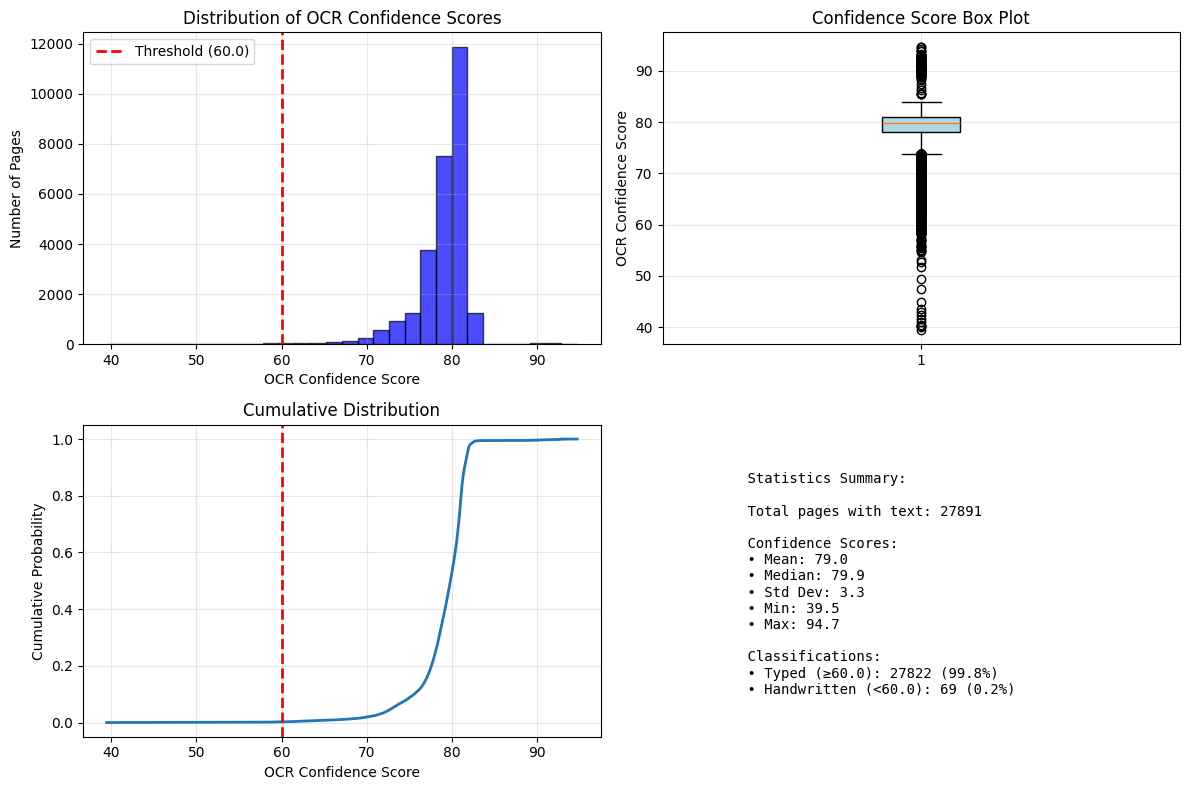


=== HANDWRITTEN PDFs SUMMARY ===
Total PDFs with handwritten pages: 24

Top PDFs by number of handwritten pages:
 1. Will Co 2014-2016.pdf
    Handwritten pages: 22
    Average confidence: 48.1

 2. Part 5.pdf
    Handwritten pages: 6
    Average confidence: 58.2

 3. Part 6.pdf
    Handwritten pages: 4
    Average confidence: 57.6
    Pages: 1, 8, 11, 29

 4. UO - FOIA June 2020.pdf
    Handwritten pages: 4
    Average confidence: 59.0
    Pages: 2, 56, 122, 180

 5. UO - FOIA November 2022.pdf
    Handwritten pages: 3
    Average confidence: 58.7
    Pages: 176, 354, 520

 6. UO - JDSU (August 2022).pdf
    Handwritten pages: 2
    Average confidence: 56.5
    Pages: 13, 153

 7. July 2021 UO FOIA.pdf
    Handwritten pages: 2
    Average confidence: 59.0
    Pages: 235, 406

 8. 2022_october.pdf
    Handwritten pages: 2
    Average confidence: 59.1
    Pages: 31, 123

 9. UO - FOIA August 2020.pdf
    Handwritten pages: 2
    Average confidence: 57.2
    Pages: 87, 154

10. FOIA - U

In [10]:
TARGET_FOLDER = Path('../data/jails-data/original')
IMAGE_DPI = 100
CONFIDENCE_THRESH = 60.0

print(f"Starting PDF analysis in folder: {TARGET_FOLDER}")
print(f"Using DPI: {IMAGE_DPI}, Confidence Threshold: {CONFIDENCE_THRESH}")
start_time = time.time()

# Use the modified function that collects scores
results, confidence_scores, handwritten_pdfs = process_all_pdfs_parallel(
    folder_path=TARGET_FOLDER,
    dpi=IMAGE_DPI,
    confidence_threshold=CONFIDENCE_THRESH
)

end_time = time.time()
processing_time = end_time - start_time

print("\n--- Analysis Complete ---")
print(f"Total pages processed: {results['total_pages_processed']}")
print(f"Typed pages: {results['typed']}")
print(f"Handwritten pages: {results['handwritten']}")
print(f"Pages with no text detected: {results['no_text_detected']}")
print(f"Pages with OCR errors: {results['ocr_error']}")
print(f"Pages with image conversion errors: {results['conversion_error']}")
print(f"Total processing time: {processing_time:.2f} seconds ({processing_time/60:.2f} minutes)")

# Create the confidence score histogram
plot_confidence_histogram(confidence_scores, CONFIDENCE_THRESH)

# Display handwritten summary
display_handwritten_summary(handwritten_pdfs)